In [ ]:
#Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    BalancedAccuracyScore
)



In [ ]:
# Cargar los datos originales
df = pd.read_parquet("../datos_credito.parquet")
df.head()

,edad,personas_a_cargo,ingreso_mensual,monto_solicitado,plazo_meses,cuota_estimada,score_crediticio,dti_previo,dti_total_proyectado,aprobado
0,61,2,1791000.0,3830000.0,24,197900.0,650,0.465,0.576,1
1,42,5,1200000.0,2720000.0,60,74500.0,705,0.288,0.350,1
2,30,0,3210000.0,22740000.0,12,2124000.0,626,0.168,0.830,1
3,40,2,1549000.0,5020000.0,48,157100.0,576,0.027,0.128,0
4,25,1,1200000.0,9120000.0,36,346400.0,439,0.129,0.418,1


In [3]:
# Separar variables predictoras y objetivo
X = df.drop(columns=["aprobado"])
y = df["aprobado"]

In [ ]:
# Dimensiones
print(X.shape)
print(y.shape)

(15000, 9)
(15000,)


In [ ]:
# Dividir entrenamiento y prueba
# 80 % para entrenamiento y 20 % para prueba
# Se utiliza stratify=y para conservar la proporción de aprobados y no aprobados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
# Pipeline modelo 1
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [7]:
#Entrenamiento
modelo.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [8]:
# Predicciones
y_pred = modelo.predict(X_test)

In [ ]:
# Probabilidad de aprobación
y_prob = modelo.predict_proba(X_test)[:, 1]

In [10]:
# Métricas de evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.732
Precision: 0.7534423407917383
Recall: 0.8834510595358224
F1: 0.8132837900603809
ROC AUC: 0.7457674076511789


In [ ]:
# Reporte de clasificación
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.66      0.44      0.53      1018
           1       0.75      0.88      0.81      1982

    accuracy                           0.73      3000
   macro avg       0.71      0.66      0.67      3000
weighted avg       0.72      0.73      0.72      3000



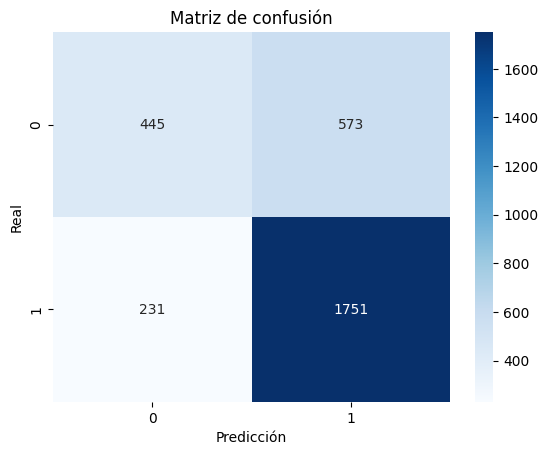

In [11]:
# Matriz de confusión
matriz = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")

plt.show()

In [ ]:
# Coeficientes del modelo 1
coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo.named_steps["classifier"].coef_[0]
})

coeficientes = coeficientes.sort_values(
    "coeficiente"
)

coeficientes

,variable,coeficiente
8,dti_total_proyectado,-0.802444
1,personas_a_cargo,-0.174042
5,cuota_estimada,-0.096750
4,plazo_meses,-0.024314
0,edad,0.005178
7,dti_previo,0.030907
3,monto_solicitado,0.131983
2,ingreso_mensual,0.246237
6,score_crediticio,0.763401


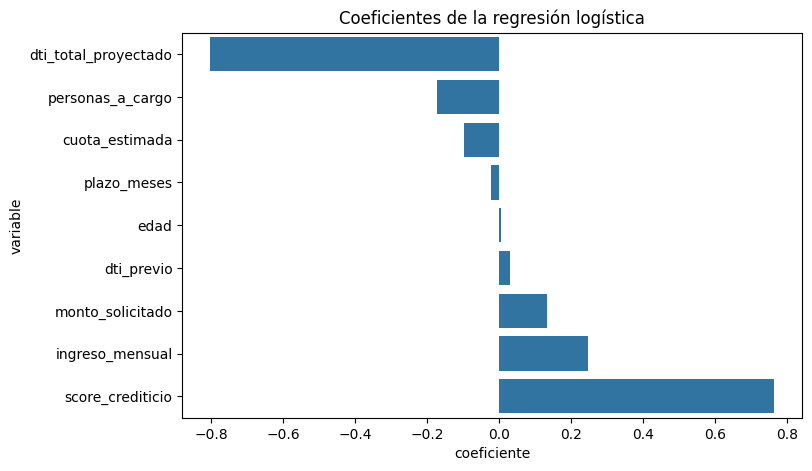

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coeficientes,
    x="coeficiente",
    y="variable"
)

plt.title("Coeficientes de la regresión logística")
plt.show()

La regresión logística inicial obtuvo un accuracy de 73,2 % y un ROC AUC de 0,746, mostrando una capacidad aceptable para discriminar entre créditos aprobados y no aprobados. El modelo presenta un alto recall para los créditos aprobados (88,3 %), aunque tiene mayores dificultades para identificar correctamente los créditos no aprobados. Los coeficientes confirman la relevancia observada durante el EDA del score crediticio y el DTI total proyectado. No obstante, algunos coeficientes presentan comportamientos distintos a sus relaciones individuales con la aprobación, lo que puede estar asociado con la alta correlación y redundancia existente entre algunos predictores. Por esta razón, se evaluará posteriormente una especificación con menor redundancia entre variables

In [ ]:
# Crear una variable que relacione el valor de la cuota con el ingreso mensual.
# Esta razón aproxima el peso de la nueva obligación sobre el ingreso del solicitante.

df["cuota_ingreso"] = (
    df["cuota_estimada"] /
    df["ingreso_mensual"]
)

In [ ]:
# Variables para el modelo 2
variables_modelo2 = [
    "personas_a_cargo",
    "ingreso_mensual",
    "score_crediticio",
    "dti_previo",
    "cuota_ingreso"
]

In [ ]:
# Separar variables predictoras y objetivo para el modelo 2
X2 = df[variables_modelo2]
y2 = df["aprobado"]

In [ ]:
# Separar entrenamiento y prueba para el modelo 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

In [ ]:
# Pipeline modelo 2
modelo2 = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [ ]:
# Entrenamiento del modelo 2
modelo2.fit(
    X2_train,
    y2_train
)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [ ]:
# Predicciones del modelo 2
y2_pred = modelo2.predict(X2_test)

y2_prob = modelo2.predict_proba(
    X2_test
)[:, 1]

In [ ]:
# Métricas de evaluación del modelo 2
print("Accuracy:", accuracy_score(y2_test, y2_pred))
print("Precision:", precision_score(y2_test, y2_pred))
print("Recall:", recall_score(y2_test, y2_pred))
print("F1:", f1_score(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_prob))

Accuracy: 0.7323333333333333
Precision: 0.7537666810159277
Recall: 0.8834510595358224
F1: 0.8134727061556329
ROC AUC: 0.7457034727082048


In [ ]:
# Reporte de clasificación del modelo 2
print(
    classification_report(
        y2_test,
        y2_pred
    )
)

              precision    recall  f1-score   support

           0       0.66      0.44      0.53      1018
           1       0.75      0.88      0.81      1982

    accuracy                           0.73      3000
   macro avg       0.71      0.66      0.67      3000
weighted avg       0.72      0.73      0.72      3000



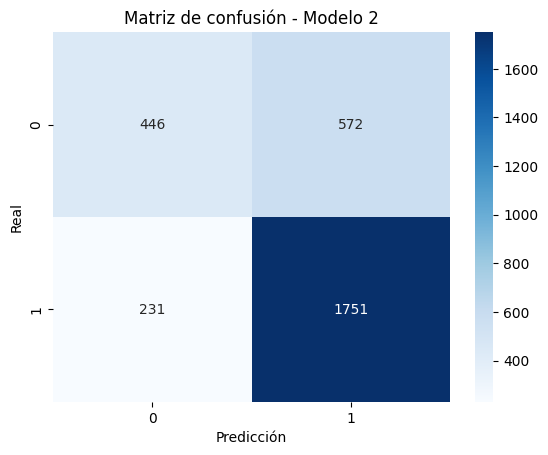

In [ ]:
# Matriz de confusión del modelo 2
matriz2 = confusion_matrix(
    y2_test,
    y2_pred
)

sns.heatmap(
    matriz2,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Modelo 2")

plt.show()

In [ ]:
# Coeficientes del modelo 2
coeficientes2 = pd.DataFrame({
    "variable": variables_modelo2,
    "coeficiente": modelo2.named_steps["classifier"].coef_[0]
})

coeficientes2 = coeficientes2.sort_values(
    "coeficiente"
)

coeficientes2

,variable,coeficiente
3,dti_previo,-0.570701
4,cuota_ingreso,-0.536619
0,personas_a_cargo,-0.174883
1,ingreso_mensual,0.286797
2,score_crediticio,0.762397


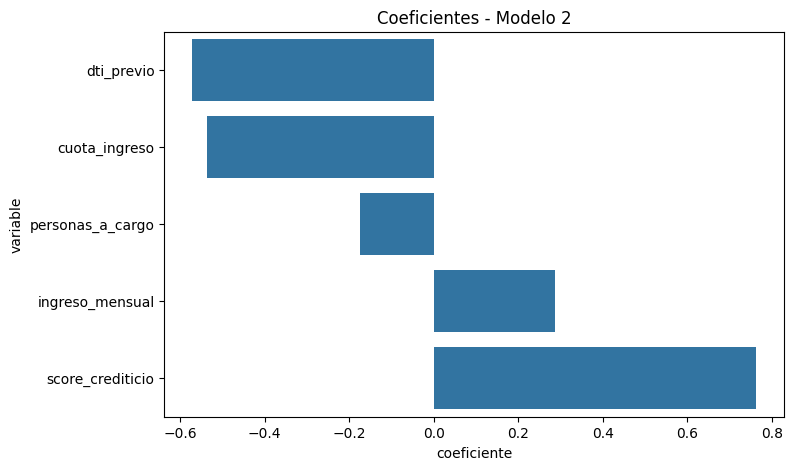

In [38]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coeficientes2,
    x="coeficiente",
    y="variable"
)

plt.title("Coeficientes - Modelo 2")

plt.show()

In [ ]:
# Comparación de métricas entre los dos modelos

resultados = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],
    
    "Modelo 1": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    
    "Modelo 2": [
        accuracy_score(y2_test, y2_pred),
        balanced_accuracy_score(y2_test, y2_pred),
        precision_score(y2_test, y2_pred),
        recall_score(y2_test, y2_pred),
        f1_score(y2_test, y2_pred),
        roc_auc_score(y2_test, y2_prob)
    ]
})

resultados

,Métrica,Modelo 1,Modelo 2
0,Accuracy,0.732000,0.732333
1,Balanced Accuracy,0.660291,0.660783
2,Precision,0.753442,0.753767
3,Recall,0.883451,0.883451
4,F1,0.813284,0.813473
5,ROC AUC,0.745767,0.745703


La reducción de variables no generó una pérdida apreciable en la capacidad predictiva del modelo. El Modelo 2 obtuvo las mismas métricas de clasificación que el modelo inicial y un ROC AUC prácticamente idéntico (0,74576 frente a 0,74577), utilizando un conjunto menor de predictores. Esto indica que parte de la información contenida en el modelo inicial era redundante, particularmente debido a las relaciones existentes entre el DTI total proyectado, el DTI previo, la cuota y el ingreso. Por su mayor simplicidad y similar desempeño, el Modelo 2 constituye hasta este punto la alternativa preferida.

In [ ]:
# Utilizar las mismas variables para Random Forest
variables_modelo3 = [
    "personas_a_cargo",
    "ingreso_mensual",
    "score_crediticio",
    "dti_previo",
    "cuota_ingreso"
]

X3 = df[variables_modelo3]
y3 = df["aprobado"]

In [ ]:
# Separar entrenamiento y prueba para el modelo 3 (Random Forest)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42,
    stratify=y3
)

In [ ]:
# Entrenamiento del modelo 3 (Random Forest)
modelo3 = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

modelo3.fit(X3_train, y3_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Predicciones del modelo 3 (Random Forest)
y3_pred = modelo3.predict(X3_test)

y3_prob = modelo3.predict_proba(X3_test)[:, 1]

In [ ]:
# Métricas de evaluación del modelo 3 (Random Forest)

print("Accuracy:", accuracy_score(y3_test, y3_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y3_test, y3_pred))
print("Precision:", precision_score(y3_test, y3_pred))
print("Recall:", recall_score(y3_test, y3_pred))
print("F1:", f1_score(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_prob))

Accuracy: 0.7086666666666667
Balanced Accuracy: 0.6423935260170612
Precision: 0.7455673758865248
Recall: 0.8486377396569122
F1: 0.7937706465313827
ROC AUC: 0.7275521441500024


In [ ]:
# Reporte de clasificación del modelo 3 (Random Forest)

print(
    classification_report(
        y3_test,
        y3_pred
    )
)

              precision    recall  f1-score   support

           0       0.60      0.44      0.50      1018
           1       0.75      0.85      0.79      1982

    accuracy                           0.71      3000
   macro avg       0.67      0.64      0.65      3000
weighted avg       0.70      0.71      0.70      3000



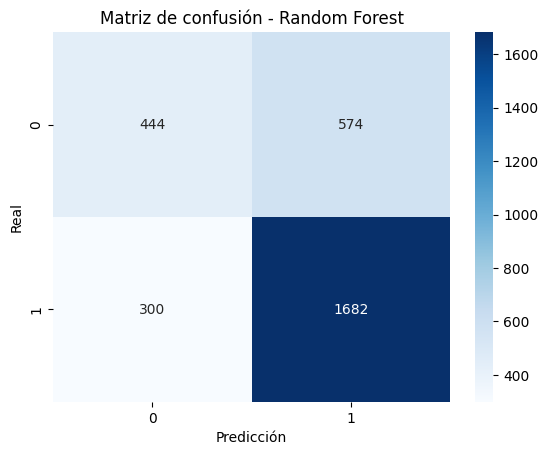

In [ ]:
# Matriz de confusión del modelo 3 (Random Forest)
matriz3 = confusion_matrix(
    y3_test,
    y3_pred
)

sns.heatmap(
    matriz3,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest")

plt.show()

In [ ]:
# Importancia de las variables del modelo 3 (Random Forest)
modelo3.feature_importances_

array([0.05801797, 0.19154284, 0.26175371, 0.24046161, 0.24822388])

In [49]:
importancias = pd.DataFrame({
    "variable": variables_modelo3,
    "importancia": modelo3.feature_importances_
})

importancias = importancias.sort_values(
    "importancia",
    ascending=False
)

importancias

,variable,importancia
2,score_crediticio,0.261754
4,cuota_ingreso,0.248224
3,dti_previo,0.240462
1,ingreso_mensual,0.191543
0,personas_a_cargo,0.058018


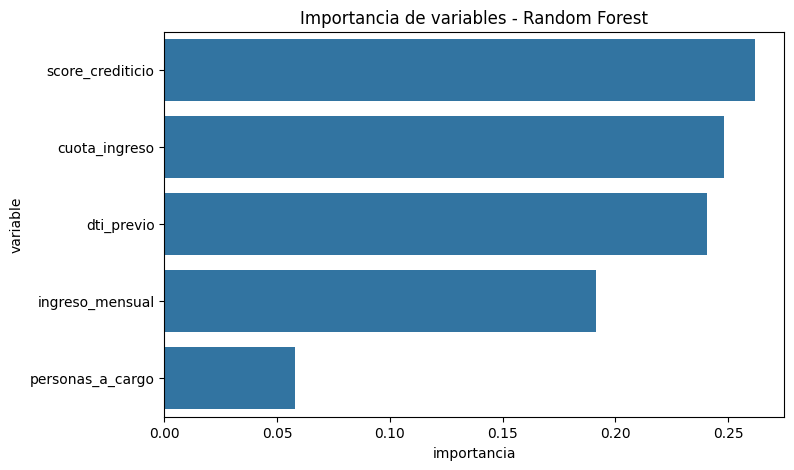

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importancias,
    x="importancia",
    y="variable"
)

plt.title("Importancia de variables - Random Forest")

plt.show()

In [ ]:
# Comparación de métricas entre los tres modelos
resultados = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],

    "Modelo 1": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],

    "Modelo 2": [
        accuracy_score(y2_test, y2_pred),
        balanced_accuracy_score(y2_test, y2_pred),
        precision_score(y2_test, y2_pred),
        recall_score(y2_test, y2_pred),
        f1_score(y2_test, y2_pred),
        roc_auc_score(y2_test, y2_prob)
    ],

    "Random Forest": [
        accuracy_score(y3_test, y3_pred),
        balanced_accuracy_score(y3_test, y3_pred),
        precision_score(y3_test, y3_pred),
        recall_score(y3_test, y3_pred),
        f1_score(y3_test, y3_pred),
        roc_auc_score(y3_test, y3_prob)
    ]
})

resultados

,Métrica,Modelo 1,Modelo 2,Random Forest
0,Accuracy,0.732000,0.732333,0.708667
1,Balanced Accuracy,0.660291,0.660783,0.642394
2,Precision,0.753442,0.753767,0.745567
3,Recall,0.883451,0.883451,0.848638
4,F1,0.813284,0.813473,0.793771
5,ROC AUC,0.745767,0.745703,0.727552


Comparación con Random Forest. Se evaluó un modelo Random Forest utilizando las mismas variables del Modelo 2 con el objetivo de explorar posibles relaciones no lineales y mejorar la identificación de créditos no aprobados. Sin embargo, el modelo obtuvo resultados inferiores a la regresión logística en todas las métricas principales, con un accuracy de 70,9 %, balanced accuracy de 64,2 % y ROC AUC de 72,8 %. Adicionalmente, no se evidenció una mejora relevante en la identificación de la clase de créditos no aprobados. Por tanto, se mantiene la regresión logística del Modelo 2 como la alternativa más adecuada hasta este punto, debido a su mejor desempeño, menor complejidad e interpretabilidad.

In [ ]:
# Variables para el modelo 4 (Gradient Boosting)
variables_modelo4 = [
    "personas_a_cargo",
    "ingreso_mensual",
    "score_crediticio",
    "dti_previo",
    "cuota_ingreso"
]

X4 = df[variables_modelo4]
y4 = df["aprobado"]

In [ ]:
# Separar entrenamiento y prueba para el modelo 4 (Gradient Boosting)
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,
    y4,
    test_size=0.20,
    random_state=42,
    stratify=y4
)

In [ ]:
# Entrenamiento del modelo 4 (Gradient Boosting)
modelo4 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

modelo4.fit(X4_train, y4_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
# Predicciones del modelo 4 (Gradient Boosting)
y4_pred = modelo4.predict(X4_test)

y4_prob = modelo4.predict_proba(X4_test)[:, 1]

In [ ]:
# Métricas de evaluación del modelo 4 (Gradient Boosting)
print("Accuracy:", accuracy_score(y4_test, y4_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y4_test, y4_pred))
print("Precision:", precision_score(y4_test, y4_pred))
print("Recall:", recall_score(y4_test, y4_pred))
print("F1:", f1_score(y4_test, y4_pred))
print("ROC AUC:", roc_auc_score(y4_test, y4_prob))

Accuracy: 0.7266666666666667
Balanced Accuracy: 0.6545827972380105
Precision: 0.7502153316106804
Recall: 0.8789101917255298
F1: 0.8094795539033457
ROC AUC: 0.7488469407377598


In [ ]:
# Reporte de clasificación del modelo 4 (Gradient Boosting)
print(
    classification_report(
        y4_test,
        y4_pred
    )
)

              precision    recall  f1-score   support

           0       0.65      0.43      0.52      1018
           1       0.75      0.88      0.81      1982

    accuracy                           0.73      3000
   macro avg       0.70      0.65      0.66      3000
weighted avg       0.71      0.73      0.71      3000



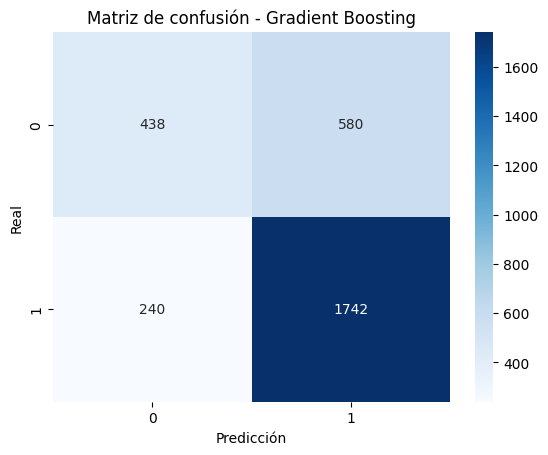

In [ ]:
# Matriz de confusión del modelo 4 (Gradient Boosting)
matriz4 = confusion_matrix(
    y4_test,
    y4_pred
)

sns.heatmap(
    matriz4,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Gradient Boosting")

plt.show()

In [ ]:
#Comparación de métricas entre los cuatro modelos
resultados = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],

    "Modelo 1": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],

    "Modelo 2": [
        accuracy_score(y2_test, y2_pred),
        balanced_accuracy_score(y2_test, y2_pred),
        precision_score(y2_test, y2_pred),
        recall_score(y2_test, y2_pred),
        f1_score(y2_test, y2_pred),
        roc_auc_score(y2_test, y2_prob)
    ],

    "Random Forest": [
        accuracy_score(y3_test, y3_pred),
        balanced_accuracy_score(y3_test, y3_pred),
        precision_score(y3_test, y3_pred),
        recall_score(y3_test, y3_pred),
        f1_score(y3_test, y3_pred),
        roc_auc_score(y3_test, y3_prob)
    ],

    "Gradient Boosting": [
        accuracy_score(y4_test, y4_pred),
        balanced_accuracy_score(y4_test, y4_pred),
        precision_score(y4_test, y4_pred),
        recall_score(y4_test, y4_pred),
        f1_score(y4_test, y4_pred),
        roc_auc_score(y4_test, y4_prob)
    ]
})

resultados

,Métrica,Modelo 1,Modelo 2,Random Forest,Gradient Boosting
0,Accuracy,0.732000,0.732333,0.708667,0.726667
1,Balanced Accuracy,0.660291,0.660783,0.642394,0.654583
2,Precision,0.753442,0.753767,0.745567,0.750215
3,Recall,0.883451,0.883451,0.848638,0.878910
4,F1,0.813284,0.813473,0.793771,0.809480
5,ROC AUC,0.745767,0.745703,0.727552,0.748847


Gradient Boosting mostró un desempeño competitivo frente a la regresión logística. Aunque sus métricas de clasificación con un umbral de 0,5 fueron ligeramente inferiores, obtuvo el mayor ROC AUC (0,749), indicando una capacidad marginalmente superior para discriminar entre solicitudes aprobadas y no aprobadas. Por esta razón, antes de seleccionar el modelo final se evaluará el efecto del umbral de clasificación sobre el balance entre ambas clases.

### Comparar umbrales para modelo 2 y boosting

La comparación anterior utiliza el umbral estándar de **0,50**. Sin embargo, en un problema de aprobación crediticia interesa analizar si un punto de corte más exigente permite identificar mejor las solicitudes no aprobadas.

A continuación se comparan distintos umbrales para los dos modelos finalistas: **Regresión Logística (Modelo 2)** y **Gradient Boosting**.

In [ ]:
umbrales = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

# Resultados para el modelo de regresión logística con diferentes umbrales
resultados_logistica = []

for umbral in umbrales:

    pred = (y2_prob >= umbral).astype(int)

    resultados_logistica.append({
        "Umbral": umbral,
        "Accuracy": accuracy_score(y2_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y2_test, pred),
        "Precision": precision_score(y2_test, pred),
        "Recall": recall_score(y2_test, pred),
        "F1": f1_score(y2_test, pred)
    })

tabla_logistica = pd.DataFrame(resultados_logistica)

tabla_logistica

,Umbral,Accuracy,Balanced Accuracy,Precision,Recall,F1
0,0.30,0.712000,0.583761,0.701224,0.982846,0.818487
1,0.35,0.719667,0.601985,0.711531,0.968214,0.820261
2,0.40,0.727000,0.624496,0.725650,0.943491,0.820355
3,0.45,0.727333,0.637410,0.735437,0.917255,0.816345
4,0.50,0.732333,0.660783,0.753767,0.883451,0.813473
5,0.55,0.726333,0.672008,0.767142,0.841070,0.802407
6,0.60,0.713333,0.676742,0.778827,0.790616,0.784677
7,0.65,0.688667,0.675991,0.793065,0.715439,0.752255
8,0.70,0.665333,0.675532,0.810673,0.643794,0.717660


In [ ]:
# Resultados para el modelo de Gradient Boosting con diferentes umbrales
resultados_gb = []

for umbral in umbrales:

    pred = (y4_prob >= umbral).astype(int)

    resultados_gb.append({
        "Umbral": umbral,
        "Accuracy": accuracy_score(y4_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y4_test, pred),
        "Precision": precision_score(y4_test, pred),
        "Recall": recall_score(y4_test, pred),
        "F1": f1_score(y4_test, pred)
    })

tabla_gb = pd.DataFrame(resultados_gb)

tabla_gb

,Umbral,Accuracy,Balanced Accuracy,Precision,Recall,F1
0,0.30,0.711667,0.583031,0.700827,0.983350,0.818392
1,0.35,0.719667,0.605330,0.713750,0.961150,0.819179
2,0.40,0.723667,0.620062,0.723190,0.942482,0.818401
3,0.45,0.727667,0.639334,0.736885,0.914228,0.816032
4,0.50,0.726667,0.654583,0.750215,0.878910,0.809480
5,0.55,0.722667,0.668278,0.764977,0.837538,0.799615
6,0.60,0.705333,0.666626,0.771513,0.787084,0.779221
7,0.65,0.696667,0.678940,0.791621,0.734107,0.761780
8,0.70,0.676000,0.682410,0.812500,0.662462,0.729850


In [ ]:
# Mejor umbral para el modelo de regresión logística según Balanced Accuracy
tabla_logistica.sort_values(
    "Balanced Accuracy",
    ascending=False
).head()

,Umbral,Accuracy,Balanced Accuracy,Precision,Recall,F1
6,0.60,0.713333,0.676742,0.778827,0.790616,0.784677
7,0.65,0.688667,0.675991,0.793065,0.715439,0.752255
8,0.70,0.665333,0.675532,0.810673,0.643794,0.717660
5,0.55,0.726333,0.672008,0.767142,0.841070,0.802407
4,0.50,0.732333,0.660783,0.753767,0.883451,0.813473


In [ ]:
# Mejor umbral para el modelo de Gradient Boosting según Balanced Accuracy
tabla_gb.sort_values(
    "Balanced Accuracy",
    ascending=False
).head()

,Umbral,Accuracy,Balanced Accuracy,Precision,Recall,F1
8,0.70,0.676000,0.682410,0.812500,0.662462,0.729850
7,0.65,0.696667,0.678940,0.791621,0.734107,0.761780
5,0.55,0.722667,0.668278,0.764977,0.837538,0.799615
6,0.60,0.705333,0.666626,0.771513,0.787084,0.779221
4,0.50,0.726667,0.654583,0.750215,0.878910,0.809480


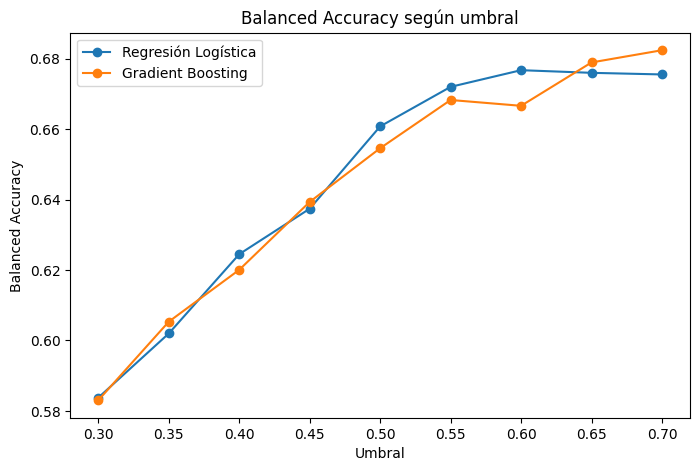

In [ ]:
# Gráfico de los umbrales para los dos modelos según Balanced Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    tabla_logistica["Umbral"],
    tabla_logistica["Balanced Accuracy"],
    marker="o",
    label="Regresión Logística"
)

plt.plot(
    tabla_gb["Umbral"],
    tabla_gb["Balanced Accuracy"],
    marker="o",
    label="Gradient Boosting"
)

plt.title("Balanced Accuracy según umbral")
plt.xlabel("Umbral")
plt.ylabel("Balanced Accuracy")
plt.legend()

plt.show()

In [ ]:
# Predicciones finales con los mejores umbrales para cada modelo
pred_logistica_final = (y2_prob >= 0.60).astype(int)
pred_gb_final = (y4_prob >= 0.70).astype(int)

In [ ]:
# Comparación de métricas finales entre los dos modelos con los mejores umbrales
comparacion_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],

    "Regresión Logística": [
        accuracy_score(y2_test, pred_logistica_final),
        balanced_accuracy_score(y2_test, pred_logistica_final),
        precision_score(y2_test, pred_logistica_final),
        recall_score(y2_test, pred_logistica_final),
        f1_score(y2_test, pred_logistica_final)
    ],

    "Gradient Boosting": [
        accuracy_score(y4_test, pred_gb_final),
        balanced_accuracy_score(y4_test, pred_gb_final),
        precision_score(y4_test, pred_gb_final),
        recall_score(y4_test, pred_gb_final),
        f1_score(y4_test, pred_gb_final)
    ]
})

comparacion_final

,Métrica,Regresión Logística,Gradient Boosting
0,Accuracy,0.713333,0.676000
1,Balanced Accuracy,0.676742,0.682410
2,Precision,0.778827,0.812500
3,Recall,0.790616,0.662462
4,F1,0.784677,0.729850


In [ ]:
# ROC AUC para los dos modelos con los mejores umbrales
print(
    "ROC AUC Logística:",
    roc_auc_score(y2_test, y2_prob)
)

print(
    "ROC AUC Gradient Boosting:",
    roc_auc_score(y4_test, y4_prob)
)

ROC AUC Logística: 0.7457034727082048
ROC AUC Gradient Boosting: 0.7488469407377598


In [ ]:
# Reporte de clasificación para el modelo de regresión logística con el mejor umbral
print("Regresión Logística")

print(
    classification_report(
        y2_test,
        pred_logistica_final,
        target_names=["No aprobado", "Aprobado"]
    )
)

Regresión Logística
              precision    recall  f1-score   support

 No aprobado       0.58      0.56      0.57      1018
    Aprobado       0.78      0.79      0.78      1982

    accuracy                           0.71      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.71      0.71      0.71      3000



In [ ]:
# Reporte de clasificación para el modelo de Gradient Boosting con el mejor umbral
print("Gradient Boosting")

print(
    classification_report(
        y4_test,
        pred_gb_final,
        target_names=["No aprobado", "Aprobado"]
    )
)

Gradient Boosting
              precision    recall  f1-score   support

 No aprobado       0.52      0.70      0.60      1018
    Aprobado       0.81      0.66      0.73      1982

    accuracy                           0.68      3000
   macro avg       0.66      0.68      0.66      3000
weighted avg       0.71      0.68      0.68      3000



Al ajustar los umbrales de clasificación se observó un cambio importante en el balance entre ambas clases. La regresión logística con umbral de 0,60 obtuvo mayor accuracy (71,3 %) y F1 (78,5 %), mientras que Gradient Boosting con umbral de 0,70 presentó mayor Balanced Accuracy (68,2 %) y una mejor capacidad para identificar créditos no aprobados, alcanzando un recall de 70 % para esta clase frente a 56 % de la regresión logística. Además, Gradient Boosting alcanzó una precisión de 81 % para las solicitudes clasificadas como aprobadas. Considerando la naturaleza del problema crediticio y la importancia de reducir aprobaciones incorrectas, Gradient Boosting se considera el candidato más adecuado para el modelo fina